In [1]:

import numpy as np
import pandas as pd

from scripts.data_filter import filter_dataframe
from scripts.data_loader import load_dataframe
from scripts.utils import NETWORK_TYPE, RF_PARAM_5G, get_config

filename = "5G_data_2023.mat"

# Series of random seeds for reproducability
random_seeds = np.loadtxt('../config/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename, NETWORK_TYPE._5G)

# # Drop unused columns to save space
matrix_cols_to_drop = ['toa_pps', 'toa_cir', 'toa_cov', 'campaign_id']
df['measurements_matrix'] = df['measurements_matrix'].apply(
    lambda x: x.drop(columns=matrix_cols_to_drop)
)

# base params
rf_param = RF_PARAM_5G.RSRQ
bands = [78]
n_best_beams = 1
n_best_pcis = None

# Get arfcn's in the n78 band
band_config = get_config("band_map.json")
selected_arfcns = [
    int(arfcn)
    for mapping in band_config.values()
    for arfcn, band in mapping.items()
    if band in bands
]

# filter bands and campaigns
df = filter_dataframe(
    df=df,
    operators=None,
    include_columns=[
        "pci",
        "beam_index",
        "nr_arfcn",
        "operator_id",
        rf_param.value,
    ],
    #freqs=selected_arfcns,
    campaigns=list(range(0, 21)),

)

# filter n best PCIs and beams
# df.loc[:, "measurements_matrix"] = df.loc[:, "measurements_matrix"].apply(
#     lambda x: matrix_filter(
#         x,
#         rf_param,
#         include_n_best_pcis=n_best_pcis,
#         include_n_best_beams=n_best_beams,
#     )
# )

print(f"Loaded df of size {df.shape}")

Loaded dataframe from .h5 file: /Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/data/dataframe_cache/5G_data_2023.h5
Loaded df of size (8415, 4)


/Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/scripts/data_filter.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["measurements_matrix"] = df["measurements_matrix"].apply(


In [13]:
from scripts.utils import dataset_tp_rp_split
from model.localization_model import LocalizationModel

all_stats = {}

n_runs = 10
cluster_range = range(1, 21)
df_tp, df_rp = dataset_tp_rp_split(df, 0.3, random_seeds[i])

data = []
for n_cl in cluster_range:
    times = []
    for i in range(n_runs):
        print(f'\rcluster {n_cl} ({i + 1}/{n_runs})', end='    ')
        loc_model = LocalizationModel(
            n_clusters=n_cl,
        )
        loc_model.fit(df_rp)
        data.append((n_cl, loc_model.training_time))

stats_df = pd.DataFrame(data, columns=["n_clusters", "training_time"])
stats_df.to_csv('training_times.csv', index=False)


cluster 20 (10/10)    

,n_clusters,training_time
0,1,11.414772
1,1,11.369001
2,1,11.369434
3,1,11.408934
4,1,11.463133
...,...,...
195,20,13.838701
196,20,14.015418
197,20,13.839396
198,20,13.828111


In [14]:
stats_df.groupby('n_clusters')['training_time'].mean()

n_clusters
1     11.396648
2     12.655775
3     13.082678
4     13.227497
5     13.417892
6     13.278107
7     13.380604
8     13.538962
9     13.640984
10    13.525040
11    13.511152
12    13.631161
13    13.651055
14    13.676316
15    14.135932
16    13.738033
17    13.814053
18    13.800689
19    13.843507
20    13.870849
Name: training_time, dtype: float64

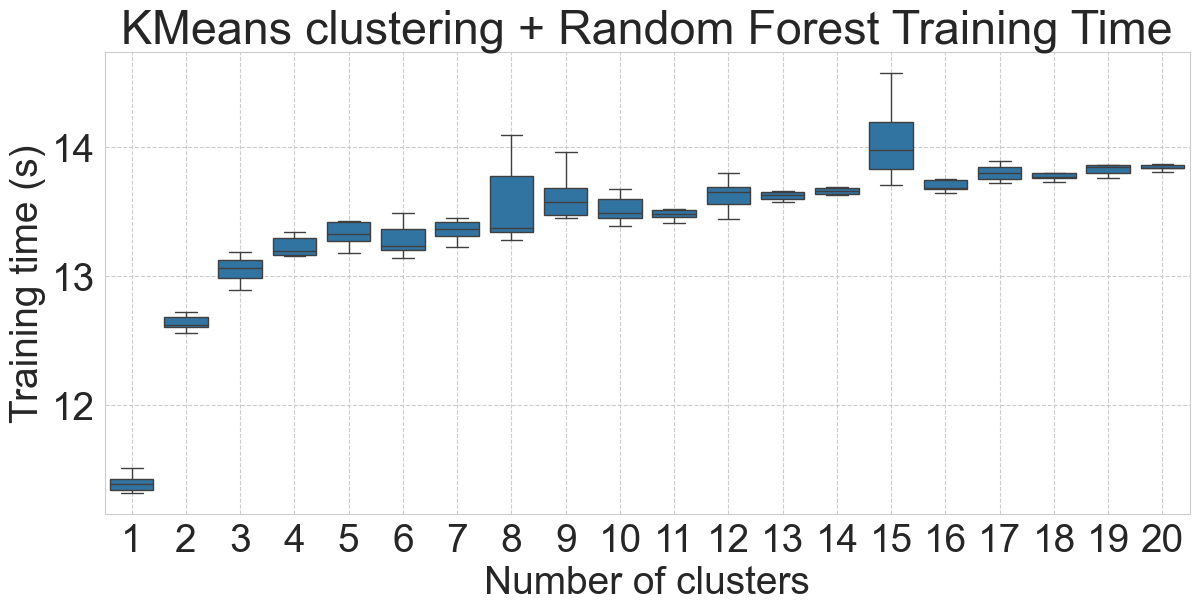

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 28

plt.figure(figsize=(14, 6))

sns.boxplot(stats_df, x="n_clusters", y="training_time", showfliers=False)

plt.grid(True, linestyle='--')
plt.xlabel('Number of clusters')
plt.ylabel('Training time (s)')
plt.title('KMeans clustering + Random Forest Training Time')
plt.savefig('training_time.png')